### 3. Exploratory Data Analysis

This notebook performs exploratory data analysis of the final preprocessed Sydney air-quality datasets. 

The analysis examines the distribution and temporal behaviour of PM2.5, relationships between PM2.5 and potential predictor variables, relationships among predictor variables, missing-data patterns, lag relationships, stationarity, and preliminary feature importance.

The purpose of this stage is to understand the characteristics and relationships within the data before machine learning modelling and explainable AI analysis are undertaken.

#### 3.1 Setup and Project Settings

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Final preprocessed data directory
final_data_dir = Path("../data/final")

# Output directories
figures_dir = Path("../results/figures")
tables_dir = Path("../results/tables")

# Retained monitoring stations
retained_stations = [
    "Camden",
    "Liverpool",
    "Parramatta North",
    "Penrith",
    "Prospect",
    "Randwick",
    "Rozelle"
]

# Target and predictor variables
target_variable = "PM2.5"

analysis_variables = [
    "PM2.5",
    "TEMP",
    "HUMID",
    "WSP",
    "WDR",
    "RAIN",
    "PM10",
    "NO2",
    "CO",
    "NO",
    "OZONE",
    "SO2"
]

print("EDA setup complete.")
print(f"Retained stations: {len(retained_stations)}")
print(f"Target variable: {target_variable}")
print(f"Potential analysis variables: {len(analysis_variables)}")

EDA setup complete.
Retained stations: 7
Target variable: PM2.5
Potential analysis variables: 12


#### 3.2 Loading the Final Preprocessed Datasets

In [4]:
# Load the final preprocessed dataset for each retained station.

eda_station_data = {}

for station in retained_stations:

    file_path = final_data_dir / f"{station}_final_preprocessed.csv"

    df = pd.read_csv(file_path)

    df["Datetime"] = pd.to_datetime(
        df["Datetime"],
        errors="coerce"
    )

    df = df.sort_values("Datetime").reset_index(drop=True)

    eda_station_data[station] = df

    print(
        f"{station}: {df.shape[0]:,} rows, "
        f"{df.shape[1] - 1} analysis variables"
    )

print("\nAll final preprocessed datasets loaded successfully.")

Camden: 57,384 rows, 11 analysis variables
Liverpool: 57,384 rows, 12 analysis variables
Parramatta North: 57,384 rows, 12 analysis variables
Penrith: 57,384 rows, 12 analysis variables
Prospect: 57,384 rows, 11 analysis variables
Randwick: 57,384 rows, 11 analysis variables
Rozelle: 57,384 rows, 12 analysis variables

All final preprocessed datasets loaded successfully.


#### 3.3 Overview of the Final Datasets

This section provides an overview of the final preprocessed datasets, including the observation period, number of observations, available variables, and remaining missing values. 

The purpose is to confirm the structure and completeness of the datasets before examining distributions and relationships between variables.

##### 3.3.1 Dataset Structure and Observation Period

In [5]:
# Summarise the structure and observation period of each station dataset.

dataset_overview = []

for station in retained_stations:

    df = eda_station_data[station]

    dataset_overview.append({
        "Station": station,
        "Rows": len(df),
        "Variables": len(df.columns) - 1,
        "Start": df["Datetime"].min(),
        "End": df["Datetime"].max()
    })

dataset_overview_df = pd.DataFrame(dataset_overview)

display(dataset_overview_df)

,Station,Rows,Variables,Start,End
0,Camden,57384,11,2020-01-01 01:00:00,2026-07-19
1,Liverpool,57384,12,2020-01-01 01:00:00,2026-07-19
2,Parramatta North,57384,12,2020-01-01 01:00:00,2026-07-19
3,Penrith,57384,12,2020-01-01 01:00:00,2026-07-19
4,Prospect,57384,11,2020-01-01 01:00:00,2026-07-19
5,Randwick,57384,11,2020-01-01 01:00:00,2026-07-19
6,Rozelle,57384,12,2020-01-01 01:00:00,2026-07-19


##### 3.3.2 Remaining Missing Values

In [6]:
# Summarise the remaining missing values in each station dataset.

missing_summary = []

for station in retained_stations:

    df = eda_station_data[station]

    for column in df.columns:

        if column == "Datetime":
            continue

        missing_count = df[column].isna().sum()

        missing_summary.append({
            "Station": station,
            "Variable": column,
            "Missing_Values": missing_count,
            "Missing_Percentage": (
                missing_count / len(df)
            ) * 100
        })

missing_summary_df = pd.DataFrame(missing_summary)

display(
    missing_summary_df[
        missing_summary_df["Missing_Values"] > 0
    ].sort_values(
        "Missing_Percentage",
        ascending=False
    )
)

,Station,Variable,Missing_Values,Missing_Percentage
63,Randwick,RANDWICK RAIN 1h average [mm/m²],24524,42.736651
28,Parramatta North,PARRAMATTA NORTH RAIN 1h average [mm/m²],20625,35.942074
5,Camden,CAMDEN RAIN 1h average [mm/m²],15164,26.425484
16,Liverpool,LIVERPOOL RAIN 1h average [mm/m²],15035,26.200683
19,Liverpool,LIVERPOOL CO 1h average [ppm],15005,26.148404
...,...,...,...,...
13,Liverpool,LIVERPOOL HUMID 1h average [%],182,0.317162
12,Liverpool,LIVERPOOL TEMP 1h average [°C],145,0.252684
27,Parramatta North,PARRAMATTA NORTH WDR 1h average [°],103,0.179493
17,Liverpool,LIVERPOOL PM10 1h average [µg/m³],87,0.151610


#### 3.4 PM2.5 Distribution Analysis

The distribution of PM2.5 concentrations is examined across the seven retained monitoring stations. 

This analysis provides an initial comparison of PM2.5 concentration levels and variability between stations and helps identify skewed distributions and potentially extreme observations for further investigation.

##### 3.4.1 Descriptive Statistics of PM2.5

In [7]:
# Calculate descriptive statistics for PM2.5 at each station.

pm25_statistics = []

for station in retained_stations:

    df = eda_station_data[station]

    pm25_column = [
        column for column in df.columns
        if "PM2.5" in column.upper()
    ][0]

    statistics = df[pm25_column].describe()

    pm25_statistics.append({
        "Station": station,
        "Count": statistics["count"],
        "Mean": statistics["mean"],
        "Std": statistics["std"],
        "Minimum": statistics["min"],
        "25th_Percentile": statistics["25%"],
        "Median": statistics["50%"],
        "75th_Percentile": statistics["75%"],
        "Maximum": statistics["max"]
    })

pm25_statistics_df = pd.DataFrame(pm25_statistics)

display(pm25_statistics_df)

,Station,Count,Mean,Std,Minimum,25th_Percentile,Median,75th_Percentile,Maximum
0,Camden,56132.0,6.560686,8.562993,0.0,2.7,5.1,8.500000,513.0
1,Liverpool,56321.0,7.798236,7.475849,0.0,3.4,6.0,10.000000,183.7
2,Parramatta North,55917.0,6.849213,6.490108,0.0,3.1,5.3,8.500000,136.6
3,Penrith,52671.0,7.715085,6.985607,0.0,3.3,6.1,10.000000,162.6
4,Prospect,54531.0,7.704760,6.856762,0.0,3.3,6.1,10.100000,145.8
5,Randwick,56827.0,6.773557,7.215910,0.0,3.2,5.5,8.670833,556.3
6,Rozelle,56964.0,6.582077,6.246655,0.0,3.1,5.3,8.300000,159.7


##### 3.4.2 PM2.5 Distribution by Station

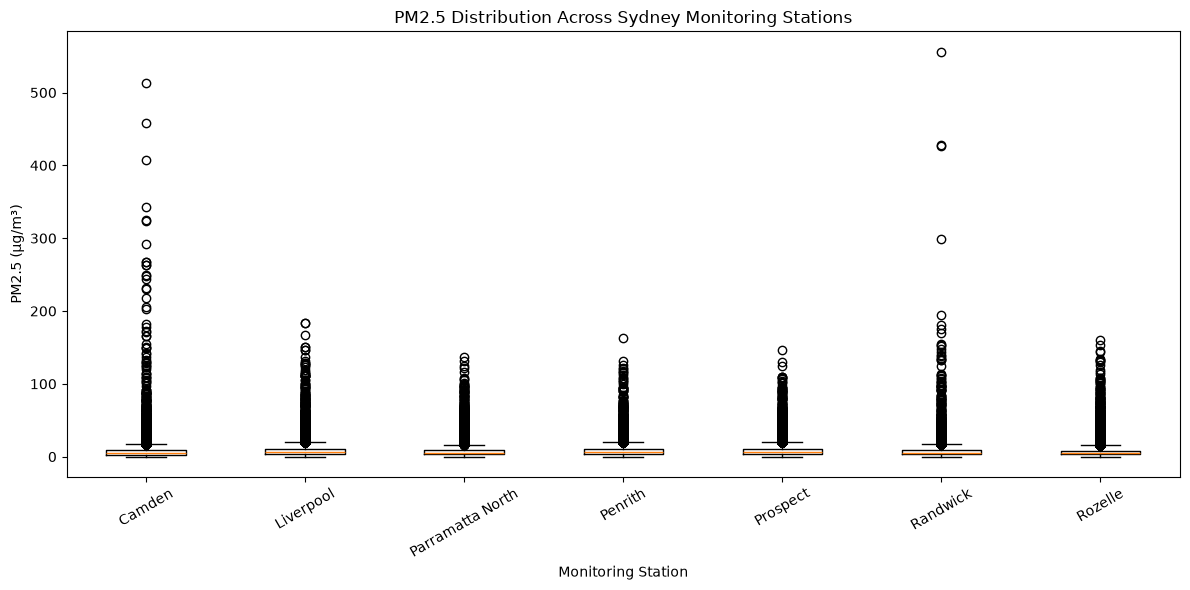

In [8]:
# Create boxplots to compare PM2.5 distributions across stations.

pm25_values = []

for station in retained_stations:

    df = eda_station_data[station]

    pm25_column = [
        column for column in df.columns
        if "PM2.5" in column.upper()
    ][0]

    pm25_values.append(
        df[pm25_column].dropna()
    )

plt.figure(figsize=(12, 6))

plt.boxplot(
    pm25_values,
    tick_labels=retained_stations,
    showfliers=True
)

plt.xlabel("Monitoring Station")
plt.ylabel("PM2.5 (µg/m³)")
plt.title("PM2.5 Distribution Across Sydney Monitoring Stations")
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig(
    figures_dir / "pm25_distribution_by_station.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

##### 3.4.3 PM2.5 Distribution Interpretation for the Boxplot

The PM2.5 distributions show a pronounced right-skew across all seven monitoring stations, with most observations concentrated at relatively low concentrations and a substantial number of high-value observations extending into the upper tail. Camden and Randwick exhibit the largest observed PM2.5 concentrations among the retained stations.

- The main box for each station is concentrated very close to the bottom of the graph, because most PM2.5 observations are relatively low.
- There are many observations above the upper whisker, shown as individual circles.
- Camden and Randwick have the most extreme values, reaching approximately 513 and 556 µg/m³, respectively.
- The other stations also have substantial high-end observations, although their maximums are lower.
- This confirms that the distributions are not symmetric and contain substantial upper-tail/extreme observations.

The boxplots identify numerous statistical outliers according to the IQR-based definition. These observations are not automatically removed because statistical extremeness does not necessarily indicate measurement error. The high-value observations will therefore be examined further during the outlier and temporal analyses to determine whether they represent unusual pollution episodes or potential data-quality issues.

#### 3.5 Temporal Analysis of PM2.5

The temporal behaviour of PM2.5 is examined to identify long-term variation, recurring patterns, and periods of elevated concentrations across the retained monitoring stations. Time-series visualisations are used to assess whether extreme PM2.5 observations occur as isolated measurements or as part of broader pollution episodes.

##### 3.5.1 PM2.5 Time Series Across Monitoring Stations

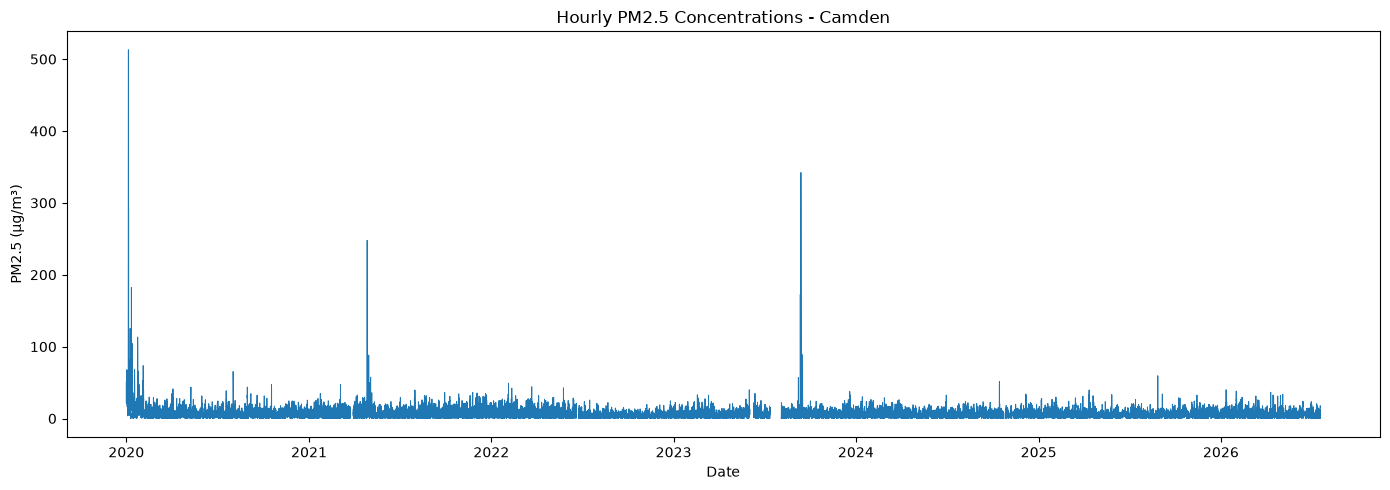

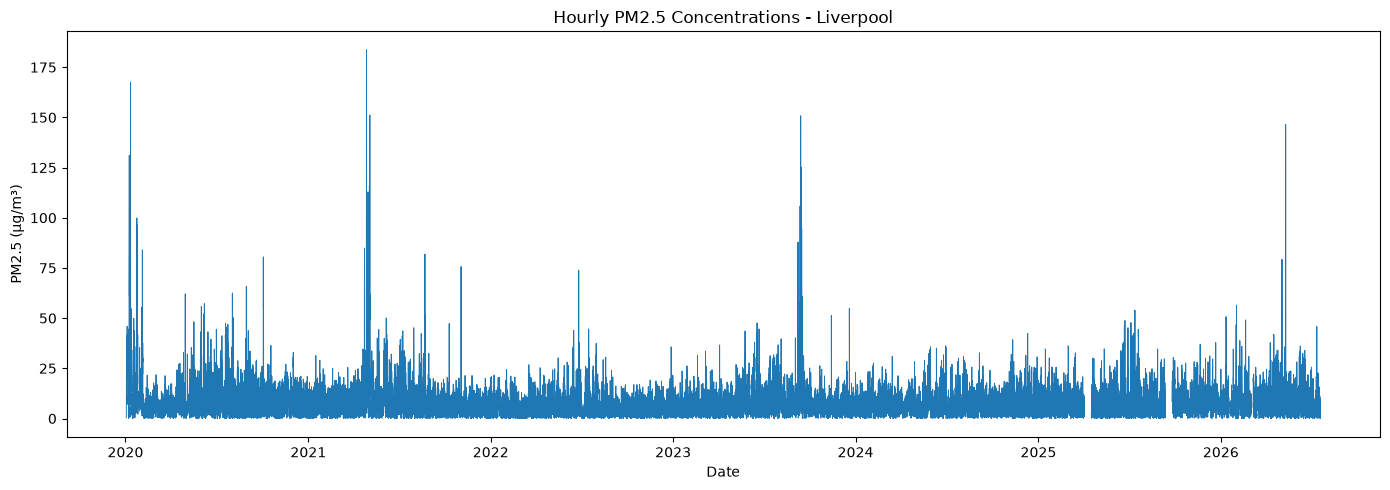

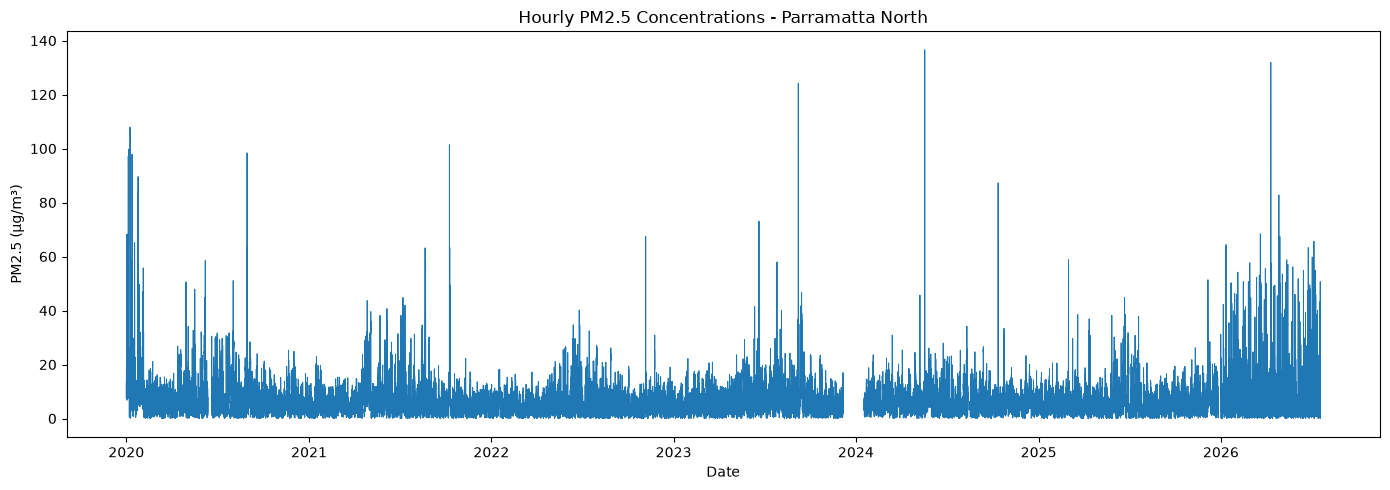

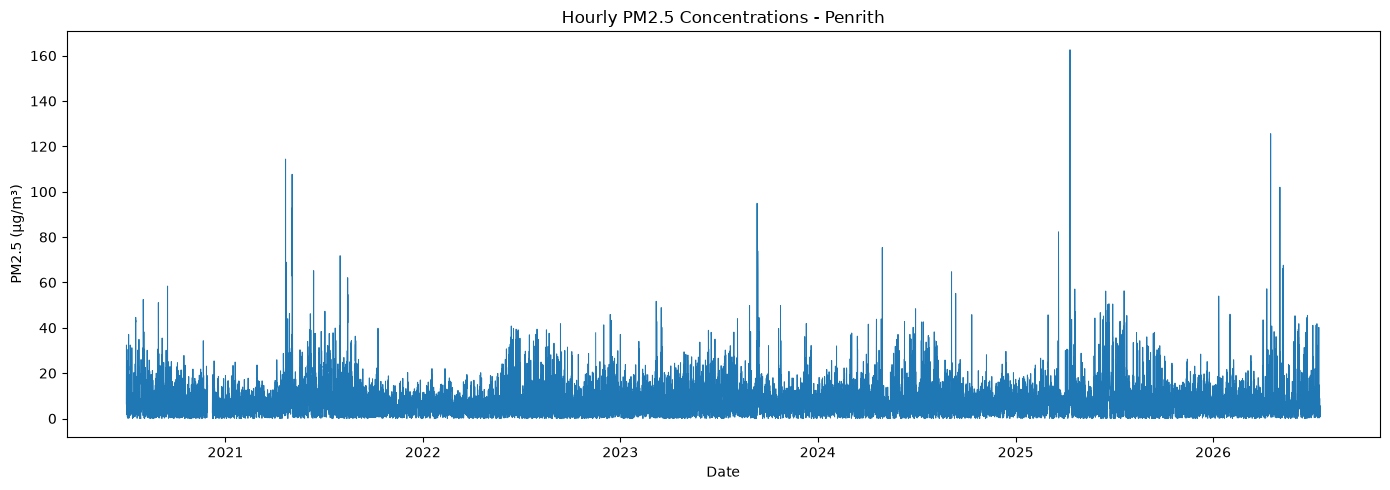

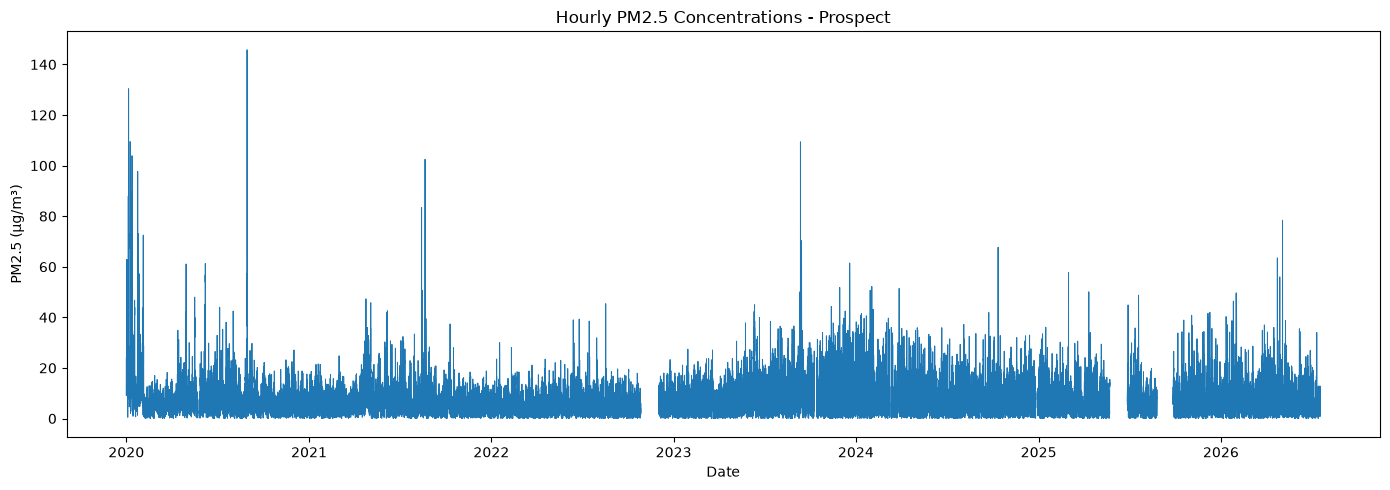

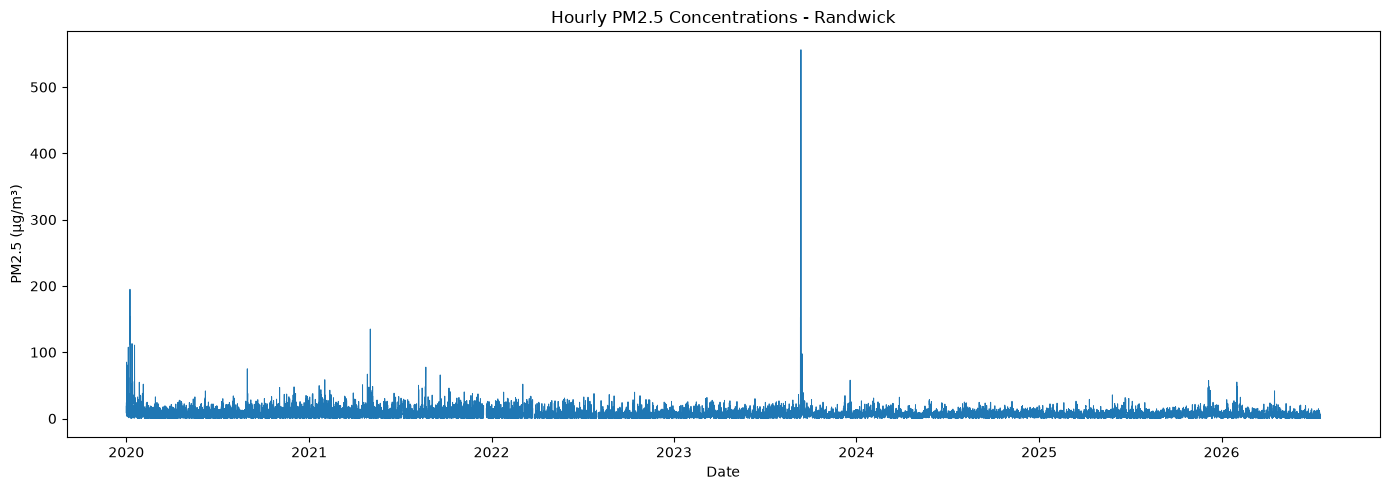

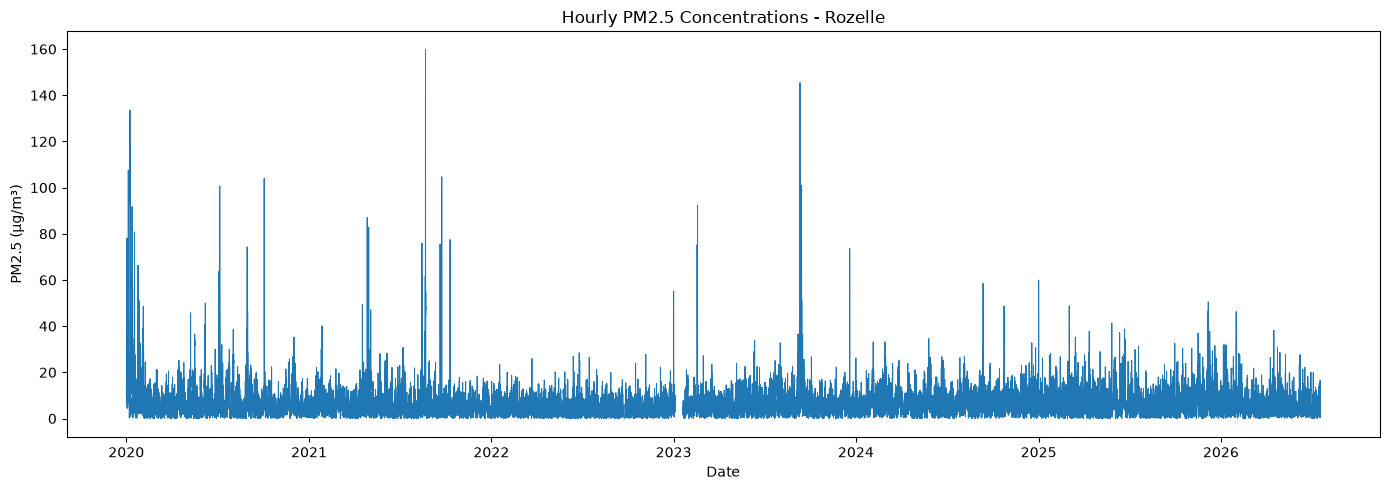

In [9]:
# Plot the hourly PM2.5 time series for each retained station.

for station in retained_stations:

    df = eda_station_data[station]

    pm25_column = [
        column for column in df.columns
        if "PM2.5" in column.upper()
    ][0]

    plt.figure(figsize=(14, 5))

    plt.plot(
        df["Datetime"],
        df[pm25_column],
        linewidth=0.7
    )

    plt.xlabel("Date")
    plt.ylabel("PM2.5 (µg/m³)")
    plt.title(f"Hourly PM2.5 Concentrations - {station}")
    plt.tight_layout()

    plt.savefig(
        figures_dir / f"pm25_time_series_{station.replace(' ', '_')}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

###### **Temporal Interpretation of PM2.5 (3.5.1)**

###### - PM2.5 concentrations are generally low across the study period, with periods of higher concentrations occurring at all stations.
###### - Elevated PM2.5 values often appear in clusters, rather than only as individual isolated observations.
###### - The frequency and magnitude of high PM2.5 periods differ between stations.
###### - Camden and Randwick contain the most extreme individual peaks, consistent with the maximum values identified in Section 3.4.1.
###### - Some stations show periods of increased PM2.5 activity during particular parts of the study period.
###### - Periods of missing observations are visible for some stations, which is consistent with the missing-value analysis from the preprocessing stage.
###### - The time-series plots show that PM2.5 varies considerably over time and between monitoring locations.
###### - The plots alone cannot determine why PM2.5 increased. Relationships with meteorological variables and other pollutants will be examined in later sections.

##### 3.5.2 Monthly Median PM2.5 by Station

###### In the previous 3.5.1, the hourly plots are too dense because of the 6 years' data.
###### Hence, below is the aggregated view to see longer-term pattens easily

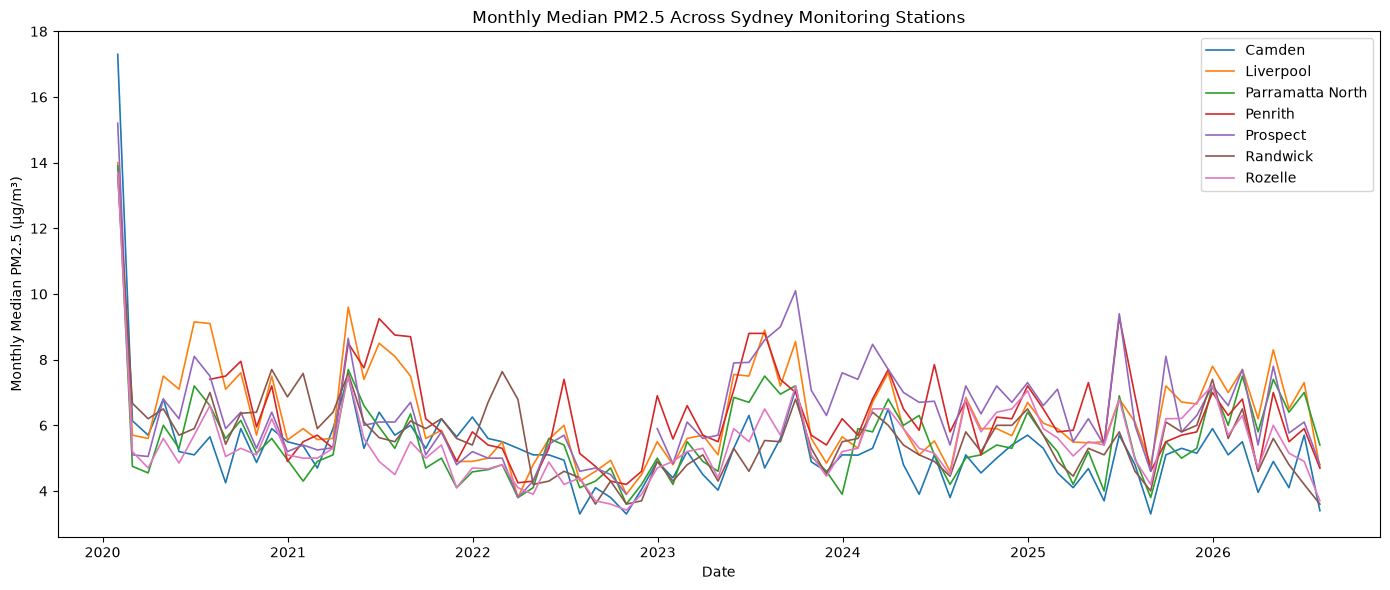

In [10]:
# Calculate and plot monthly median PM2.5 concentrations for each station.

plt.figure(figsize=(14, 6))

for station in retained_stations:

    df = eda_station_data[station].copy()

    pm25_column = [
        column for column in df.columns
        if "PM2.5" in column.upper()
    ][0]

    monthly_pm25 = (
        df.set_index("Datetime")[pm25_column]
        .resample("ME")
        .median()
    )

    plt.plot(
        monthly_pm25.index,
        monthly_pm25.values,
        label=station,
        linewidth=1.2
    )

plt.xlabel("Date")
plt.ylabel("Monthly Median PM2.5 (µg/m³)")
plt.title("Monthly Median PM2.5 Across Sydney Monitoring Stations")
plt.legend()
plt.tight_layout()

plt.savefig(
    figures_dir / "monthly_median_pm25_by_station.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

###### **Temporal Interpretation of Monthly Median PM2.5 (3.5.2)**

###### - Monthly median PM2.5 generally remains within a relatively low range for most of the study period, with several periods of higher concentrations.
###### - The stations show similar increases and decreases during several periods, although the magnitude differs between locations.
###### - Prospect and Liverpool are often toward the higher end of the monthly median PM2.5 values, while Camden and Randwick are often lower during many periods.
###### - Several stations show unusually high monthly median PM2.5 values at the beginning of 2020.
###### - Periods of increased PM2.5 activity are also visible around parts of 2021, 2023–2024, and 2025–2026.
###### - The monthly plot shows that PM2.5 variation occurs both between stations and across time.
###### - Monthly aggregation makes the longer-term patterns easier to observe than the hourly time-series plots.
###### - The plot does not by itself explain the causes of these variations, which will be investigated using relationships with meteorological variables and other pollutants.

#### 3.6 Outlier Analysis

Potential statistical outliers in PM2.5 are identified using the Interquartile Range (IQR) method. 

The purpose of this analysis is to quantify the number and proportion of observations outside the IQR-based limits and determine whether extreme observations require further investigation. Statistical outliers are not automatically treated as errors because unusually high PM2.5 concentrations may represent genuine pollution episodes.

##### 3.6.1 IQR-Based PM2.5 Outlier Detection

In [11]:
# Identify PM2.5 observations outside the IQR-based limits for each station.

pm25_outlier_summary = []

for station in retained_stations:

    df = eda_station_data[station]

    pm25_column = [
        column for column in df.columns
        if "PM2.5" in column.upper()
    ][0]

    pm25 = df[pm25_column].dropna()

    q1 = pm25.quantile(0.25)
    q3 = pm25.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = pm25[
        (pm25 < lower_bound) |
        (pm25 > upper_bound)
    ]

    pm25_outlier_summary.append({
        "Station": station,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": len(outliers),
        "Valid_Observations": len(pm25),
        "Outlier_Percentage": (
            len(outliers) / len(pm25)
        ) * 100
    })

pm25_outlier_summary_df = pd.DataFrame(
    pm25_outlier_summary
)

display(pm25_outlier_summary_df)

,Station,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Valid_Observations,Outlier_Percentage
0,Camden,2.7,8.500000,5.800000,-6.00000,17.200000,2224,56132,3.962089
1,Liverpool,3.4,10.000000,6.600000,-6.50000,19.900000,2797,56321,4.966176
2,Parramatta North,3.1,8.500000,5.400000,-5.00000,16.600000,3077,55917,5.502799
3,Penrith,3.3,10.000000,6.700000,-6.75000,20.050000,2530,52671,4.803402
4,Prospect,3.3,10.100000,6.800000,-6.90000,20.300000,2341,54531,4.292971
5,Randwick,3.2,8.670833,5.470833,-5.00625,16.877083,2465,56827,4.337727
6,Rozelle,3.1,8.300000,5.200000,-4.70000,16.100000,2736,56964,4.803033


###### **Interpretation for IQR-based outliers (3.6.1)**

###### - IQR-based outliers account for roughly 4.0–5.5% of valid PM2.5 observations across the stations.
###### - Parramatta North has the highest proportion: 5.50%.
###### - Liverpool has the second highest: 4.97%.
###### - Camden has the lowest: 3.96%.
###### - The calculated lower bounds are negative at every station. Since PM2.5 cannot be negative, the meaningful IQR outliers here are therefore the high-side observations above the upper bound.
###### - This supports what we saw in the boxplot: there are a substantial number of unusually high PM2.5 observations, but that alone does not mean they are erroneous.

##### 3.6.2 Extreme PM2.5 Observations

The highest PM2.5 observations are examined together with their timestamps to determine whether extreme values occur as isolated observations or during identifiable periods of elevated concentration. This helps distinguish statistical outliers from broader pollution episodes that may require further investigation.

In [12]:
# Extract the highest PM2.5 observations and their timestamps for each station.

extreme_pm25 = []

for station in retained_stations:

    df = eda_station_data[station]

    pm25_column = [
        column for column in df.columns
        if "PM2.5" in column.upper()
    ][0]

    station_extremes = (
        df[["Datetime", pm25_column]]
        .dropna()
        .sort_values(
            pm25_column,
            ascending=False
        )
        .head(10)
        .copy()
    )

    station_extremes["Station"] = station
    station_extremes = station_extremes.rename(
        columns={pm25_column: "PM2.5"}
    )

    extreme_pm25.append(
        station_extremes[
            ["Station", "Datetime", "PM2.5"]
        ]
    )

extreme_pm25_df = pd.concat(
    extreme_pm25,
    ignore_index=True
)

display(
    extreme_pm25_df.sort_values(
        "PM2.5",
        ascending=False
    )
)

,Station,Datetime,PM2.5
50,Randwick,2023-09-12 04:00:00,556.30
0,Camden,2020-01-05 06:00:00,513.00
1,Camden,2020-01-05 05:00:00,458.40
51,Randwick,2023-09-12 05:00:00,427.45
52,Randwick,2023-09-12 03:00:00,427.00
...,...,...,...
27,Parramatta North,2020-01-08 17:00:00,105.10
48,Prospect,2020-01-12 12:00:00,103.90
49,Prospect,2021-08-21 06:00:00,102.50
28,Parramatta North,2021-10-09 02:00:00,101.40


###### **Outlier Interpretation of PM2.5 (3.6.2)**

###### - The highest PM2.5 observations are concentrated within specific periods rather than being evenly distributed across the study period.
###### - Some extreme values occur during consecutive hours, such as the high observations recorded at Randwick on 12 September 2023 and Camden on 5 January 2020.
###### - This suggests that some statistical outliers may be associated with broader periods of elevated PM2.5 rather than isolated observations.
###### - Camden and Randwick contain the largest individual PM2.5 observations in the dataset.
###### - The magnitude and timing of extreme observations differ between monitoring stations.
###### - The causes of these high PM2.5 observations cannot be determined from the PM2.5 series alone and will be investigated through relationships with other pollutants and meteorological variables.

#### 3.7 Correlation Analysis

Correlation analysis is used to examine the linear relationships between PM2.5 and the available meteorological and pollutant variables at each monitoring station. The analysis provides an initial indication of which variables are positively or negatively associated with PM2.5 and helps guide the subsequent relationship and feature-importance analyses.

##### 3.7.1 Correlation of PM2.5 with Potential Predictors

###### Pearson correlations will give us an initial measure of linear association b/w PM2.5 and other predictors at other stations

###### Correlation tells the strength and direction of a linear association


In [13]:
# Calculate Pearson correlations between PM2.5 and the available analysis variables.

pm25_correlations = []

for station in retained_stations:

    df = eda_station_data[station].copy()

    numeric_columns = [
        column for column in df.columns
        if column != "Datetime"
    ]

    correlation_matrix = df[numeric_columns].corr(
        method="pearson"
    )

    pm25_column = [
        column for column in numeric_columns
        if "PM2.5" in column.upper()
    ][0]

    for column in numeric_columns:

        if column == pm25_column:
            continue

        pm25_correlations.append({
            "Station": station,
            "Variable": column,
            "Pearson_Correlation": correlation_matrix.loc[
                pm25_column, column
            ]
        })

pm25_correlations_df = pd.DataFrame(
    pm25_correlations
)

display(
    pm25_correlations_df.sort_values(
        ["Station", "Pearson_Correlation"],
        ascending=[True, False]
    )
)

,Station,Variable,Pearson_Correlation
5,Camden,CAMDEN PM10 1h average [µg/m³],0.601654
7,Camden,CAMDEN CO 1h average [ppm],0.537038
6,Camden,CAMDEN NO2 1h average [pphm],0.279784
8,Camden,CAMDEN NO 1h average [pphm],0.102371
1,Camden,CAMDEN HUMID 1h average [%],0.067788
...,...,...,...
66,Rozelle,ROZELLE WDR 1h average [°],0.047704
63,Rozelle,ROZELLE TEMP 1h average [°C],-0.004371
65,Rozelle,ROZELLE WSP 1h average [m/s],-0.027117
67,Rozelle,ROZELLE RAIN 1h average [mm/m²],-0.035625


In [14]:
# Save the complete PM2.5 correlation results.

correlation_output_path = tables_dir / "pm25_correlations_by_station.csv"

pm25_correlations_df.sort_values(
    ["Station", "Pearson_Correlation"],
    ascending=[True, False]
).to_csv(
    correlation_output_path,
    index=False
)

print(f"Correlation results saved to: {correlation_output_path}")

Correlation results saved to: ..\results\tables\pm25_correlations_by_station.csv


###### **Correlation Interpretation of PM2.5 (3.7.1)**

###### - PM10 shows a strong positive correlation with PM2.5 at most monitoring stations, with correlations around 0.50–0.60 at six of the seven stations.
###### - CO also shows a relatively strong positive correlation with PM2.5 at most stations where it is available.
###### - NO and NO2 generally show positive relationships with PM2.5, although the strength varies between stations.
###### - Temperature, wind speed and ozone generally show negative correlations with PM2.5, but these relationships are mostly weak to moderate.
###### - Rainfall and wind direction show relatively weak correlations with PM2.5 across the stations.
###### - Penrith differs from the other stations because its correlation between PM2.5 and PM10 is very weak, while NO2 and NO have the strongest positive correlations with PM2.5 at this station.
###### - Overall, the correlation results suggest that pollutant variables, particularly PM10 and CO, have stronger linear associations with PM2.5 than most meteorological variables.
###### - These correlations indicate association rather than causation and will be complemented by further relationship and feature-importance analyses.

##### 3.7.2 Correlation Heatmap

A heatmap is used to visualise the Pearson correlation between PM2.5 and the available predictor variables across the seven monitoring stations. 

This provides a visual comparison of the strength and direction of the relationships identified in Section 3.7.1.

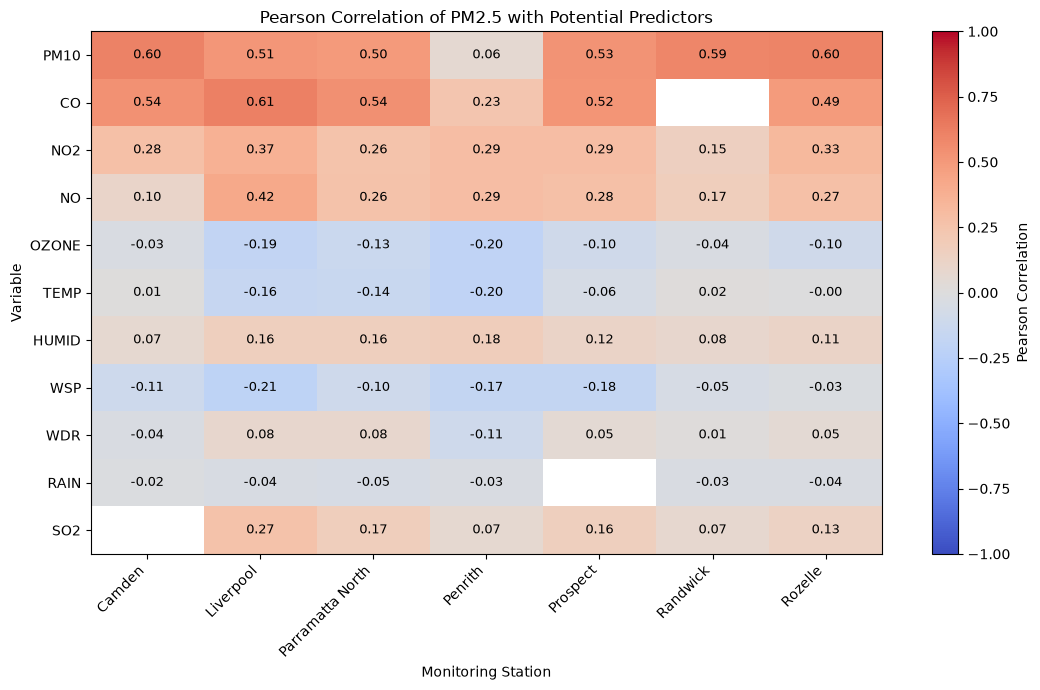

In [15]:
# Prepare correlation data for heatmap
correlation_heatmap_data = pm25_correlations_df.copy()

# Extract short variable names from the original variable names
correlation_heatmap_data["Variable_Short"] = (
    correlation_heatmap_data["Variable"]
    .str.extract(r"\s([A-Z0-9.]+)\s+1h average")[0]
)

# Reshape data for the heatmap
correlation_heatmap_data = correlation_heatmap_data.pivot(
    index="Variable_Short",
    columns="Station",
    values="Pearson_Correlation"
)

# Reorder stations
correlation_heatmap_data = correlation_heatmap_data.reindex(
    columns=retained_stations
)

# Reorder variables
variable_order = [
    "PM10",
    "CO",
    "NO2",
    "NO",
    "OZONE",
    "TEMP",
    "HUMID",
    "WSP",
    "WDR",
    "RAIN",
    "SO2"
]

correlation_heatmap_data = correlation_heatmap_data.reindex(
    variable_order
)

# Create heatmap
plt.figure(figsize=(11, 7))

plt.imshow(
    correlation_heatmap_data,
    aspect="auto",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Pearson Correlation")

plt.xticks(
    range(len(correlation_heatmap_data.columns)),
    correlation_heatmap_data.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_heatmap_data.index)),
    correlation_heatmap_data.index
)

# Add correlation values to cells
for i in range(correlation_heatmap_data.shape[0]):
    for j in range(correlation_heatmap_data.shape[1]):
        value = correlation_heatmap_data.iloc[i, j]

        if pd.notna(value):
            plt.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=9
            )

plt.xlabel("Monitoring Station")
plt.ylabel("Variable")
plt.title("Pearson Correlation of PM2.5 with Potential Predictors")

plt.tight_layout()

plt.savefig(
    figures_dir / "pm25_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

###### **Correlation Heatmap Interpretation (3.7.2)**

###### - The heatmap shows that PM10 has a relatively strong positive correlation with PM2.5 at most monitoring stations.
###### - CO also shows relatively strong positive correlations with PM2.5 at stations where it is available.
###### - NO and NO2 generally show positive correlations with PM2.5, although the strength varies between stations.
###### - OZONE and wind speed generally show negative correlations with PM2.5, while temperature shows weaker negative relationships at several stations.
###### - Humidity generally shows weak positive correlations with PM2.5.
###### - Wind direction and rainfall show mostly weak correlations with PM2.5 across the monitoring stations.
###### - The heatmap highlights differences between stations, particularly the much weaker PM10–PM2.5 relationship at Penrith compared with the other stations.
###### - Overall, the strongest linear associations with PM2.5 are generally observed for pollutant variables such as PM10 and CO rather than the meteorological variables.
###### - These results show correlation rather than causation and will be used as an initial guide for further feature-importance and modelling analyses.

#### 3.8 Relationship Analysis

Scatterplots are used to examine the relationships between PM2.5 and selected meteorological and pollutant variables.

This provides a visual assessment of the patterns identified through the Pearson correlation analysis and helps determine whether the relationships appear approximately linear or show substantial variation.

##### 3.8.1 PM2.5 vs Key Predictor Variables

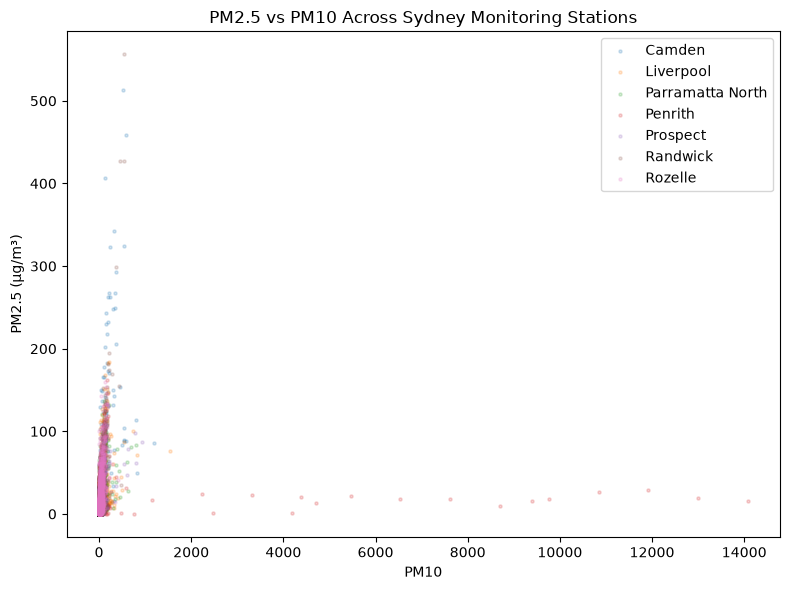

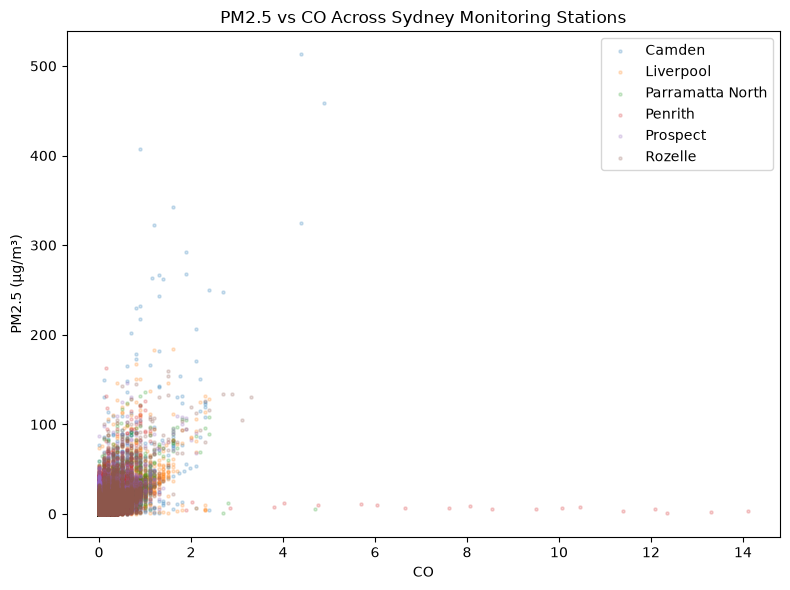

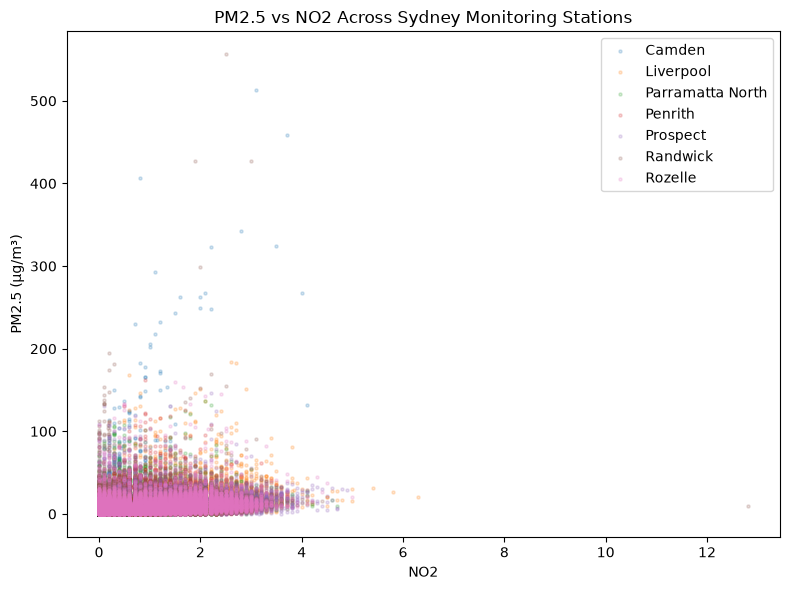

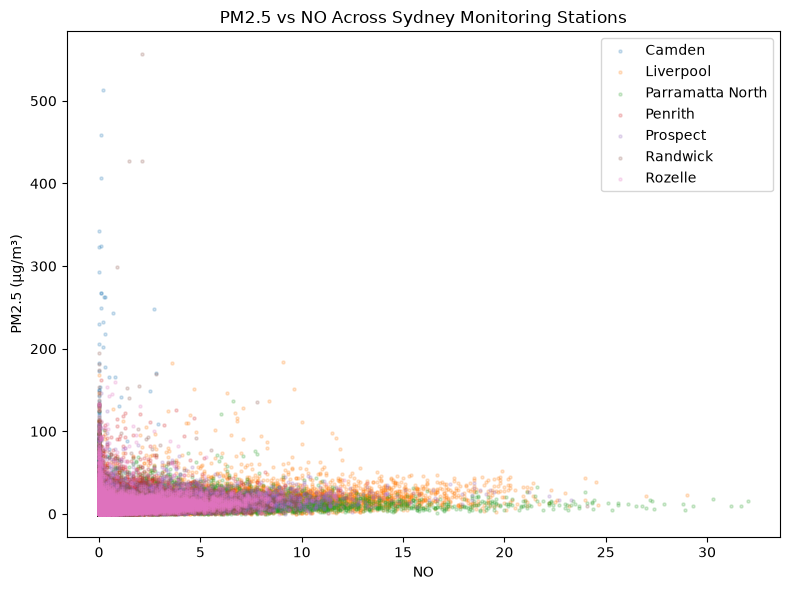

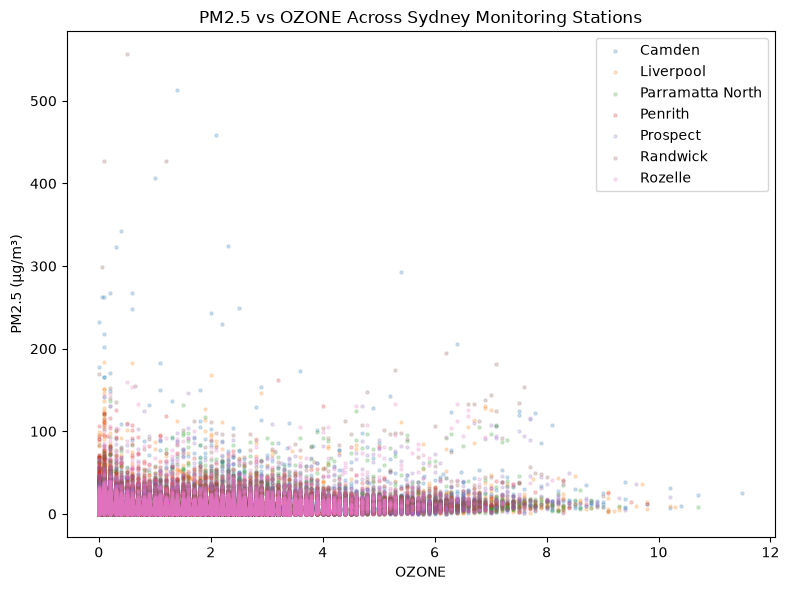

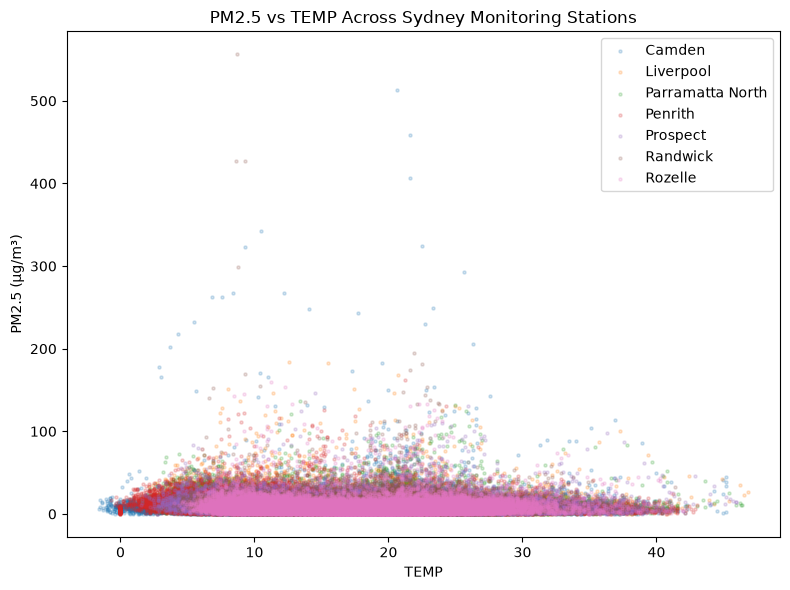

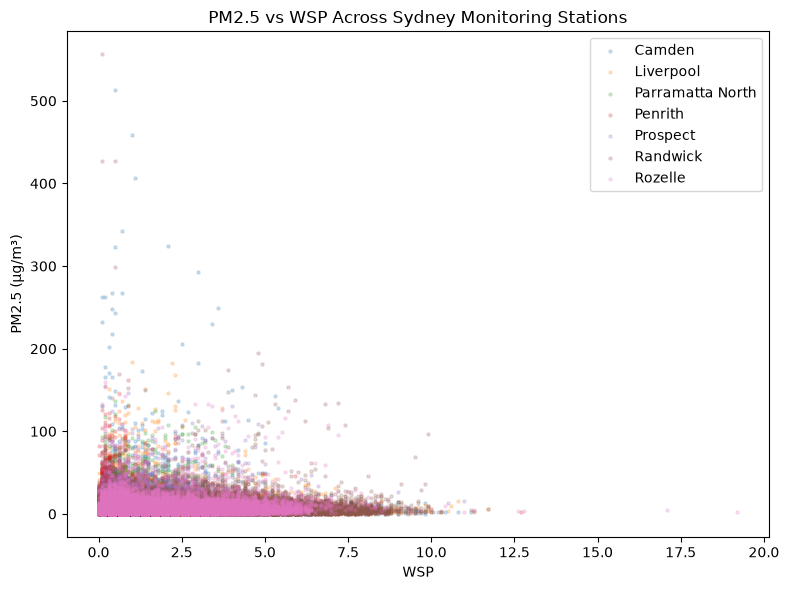

In [16]:
# Selected variables for relationship analysis
selected_relationship_variables = [
    "PM10",
    "CO",
    "NO2",
    "NO",
    "OZONE",
    "TEMP",
    "WSP"
]

for variable in selected_relationship_variables:
    plt.figure(figsize=(8, 6))

    plotted_any = False

    for station in retained_stations:
        df = eda_station_data[station].copy()

        # Identify PM2.5 column
        pm25_column = [
            column for column in df.columns
            if "PM2.5" in column.upper()
        ][0]

        # Find the exact variable name from the full column names
        matching_columns = []

        for column in df.columns:
            short_name = (
                column
                .upper()
                .split(" 1H AVERAGE")[0]
                .split()[-1]
            )

            if short_name == variable.upper():
                matching_columns.append(column)

        if not matching_columns:
            continue

        variable_column = matching_columns[0]

        plot_data = df[[pm25_column, variable_column]].dropna()

        if plot_data.empty:
            continue

        plt.scatter(
            plot_data[variable_column],
            plot_data[pm25_column],
            s=5,
            alpha=0.2,
            label=station
        )

        plotted_any = True

    if plotted_any:
        plt.xlabel(variable)
        plt.ylabel("PM2.5 (µg/m³)")
        plt.title(f"PM2.5 vs {variable} Across Sydney Monitoring Stations")
        plt.legend()
        plt.tight_layout()

        plt.savefig(
            figures_dir / f"pm25_vs_{variable.lower()}_scatter.png",
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

###### **Relationship Interpretation (3.8.1)**

###### - The PM2.5 versus PM10 scatterplot shows a clear positive relationship, with higher PM10 values generally associated with higher PM2.5 concentrations.
###### - The PM2.5 versus CO plot also shows a positive relationship, although the observations are widely scattered, particularly at lower CO concentrations.
###### - PM2.5 shows a positive but more variable relationship with NO2 and NO, with higher PM2.5 concentrations occurring across a range of pollutant concentrations.
###### - The PM2.5 versus OZONE plot shows a generally weak negative tendency, consistent with the negative Pearson correlations identified in Section 3.7.
###### - The relationship between PM2.5 and temperature is relatively scattered, with no strong simple linear pattern clearly visible across all stations.
###### - PM2.5 generally decreases as wind speed increases, supporting the weak-to-moderate negative correlations observed for WSP.
###### - The scatterplots show substantial variation between monitoring stations and considerable spread in the observations.
###### - Extreme PM2.5 observations remain visible in several relationships, particularly at higher PM2.5 concentrations.
###### - Overall, the scatterplots support the correlation analysis while showing that the relationships are not perfectly linear and may be influenced by other variables and temporal factors.

##### 3.8.2 Relationships Between Predictor Variables

The relationships between the predictor variables are examined to identify potential associations among the input variables. This provides an initial assessment of whether some predictors show similar patterns and may contain overlapping information.

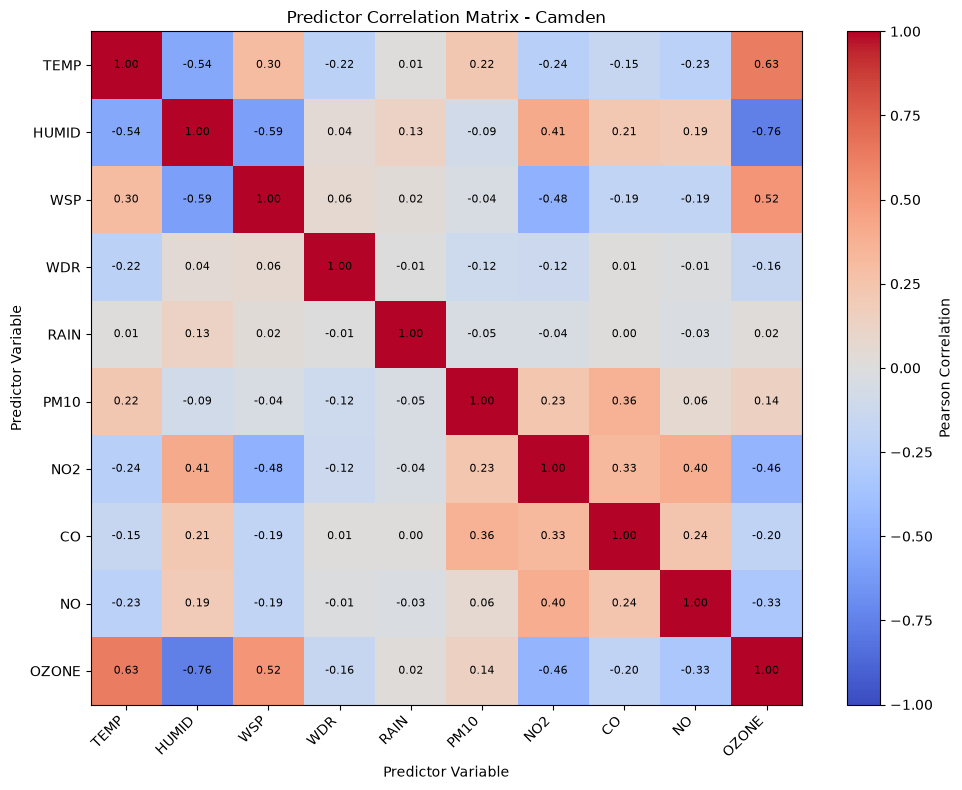

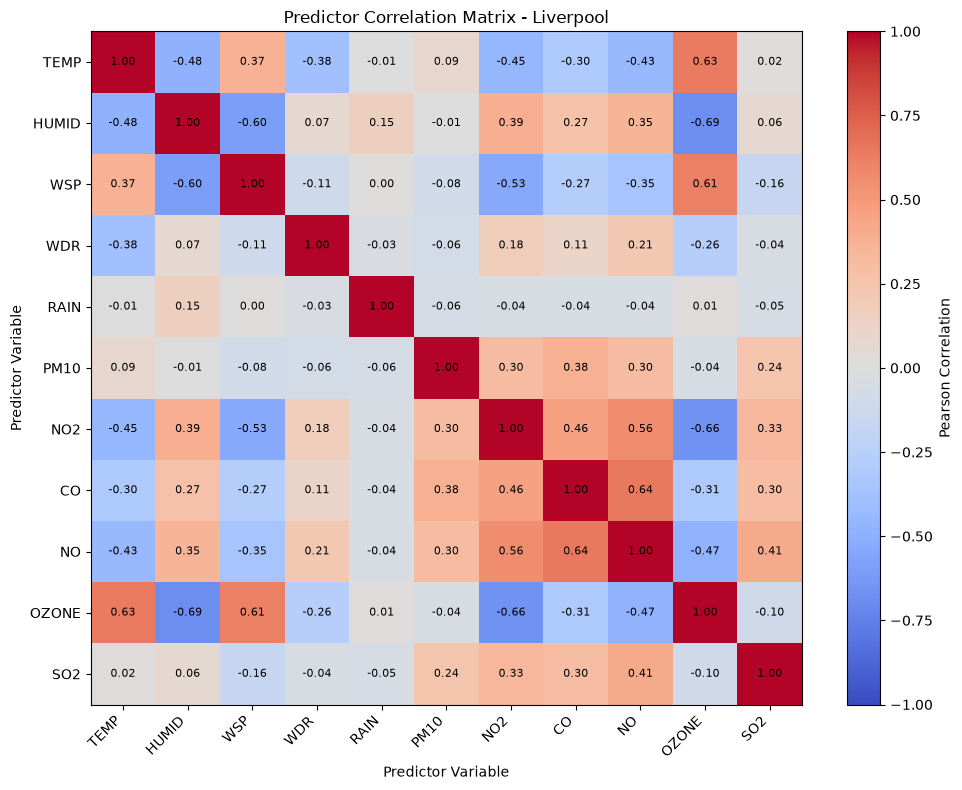

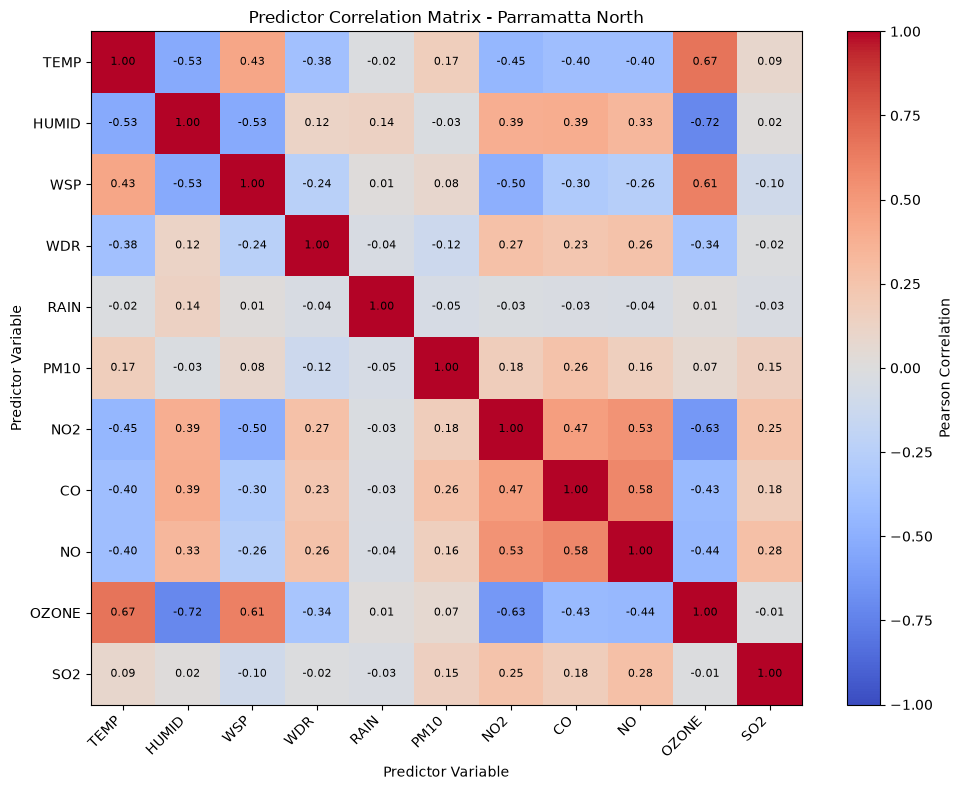

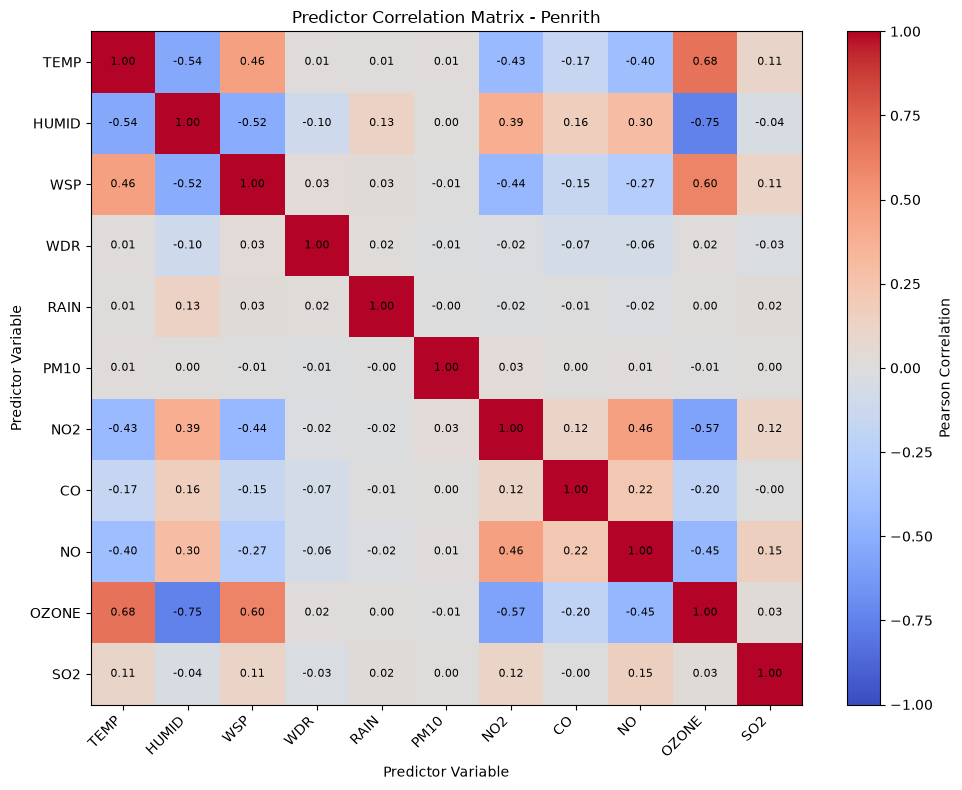

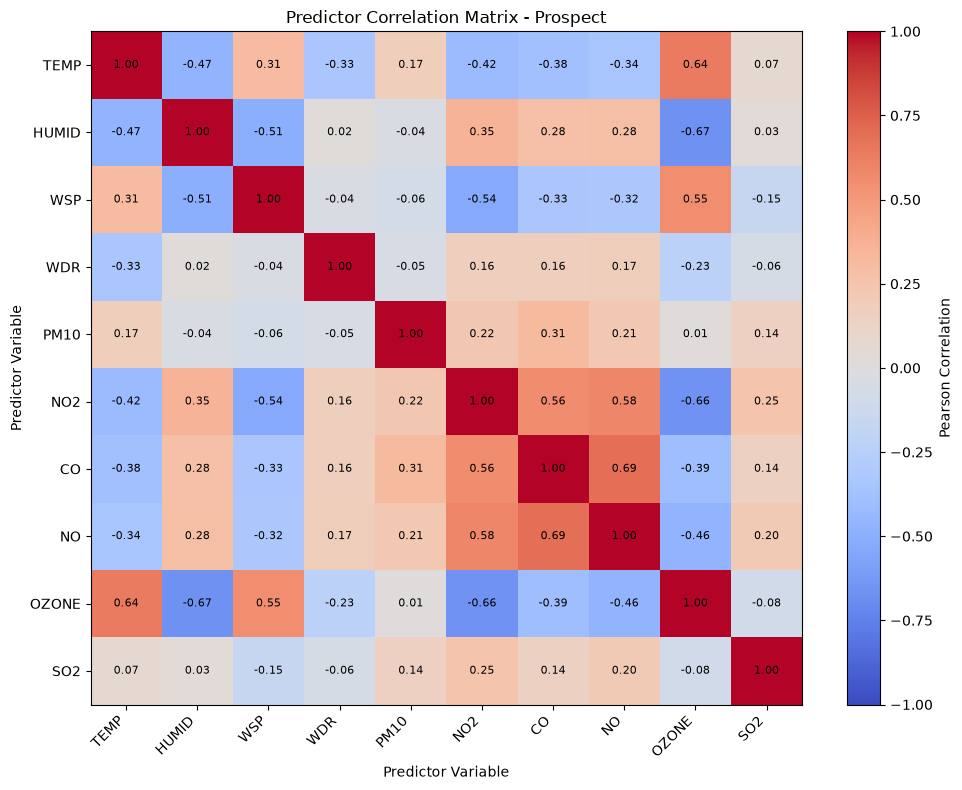

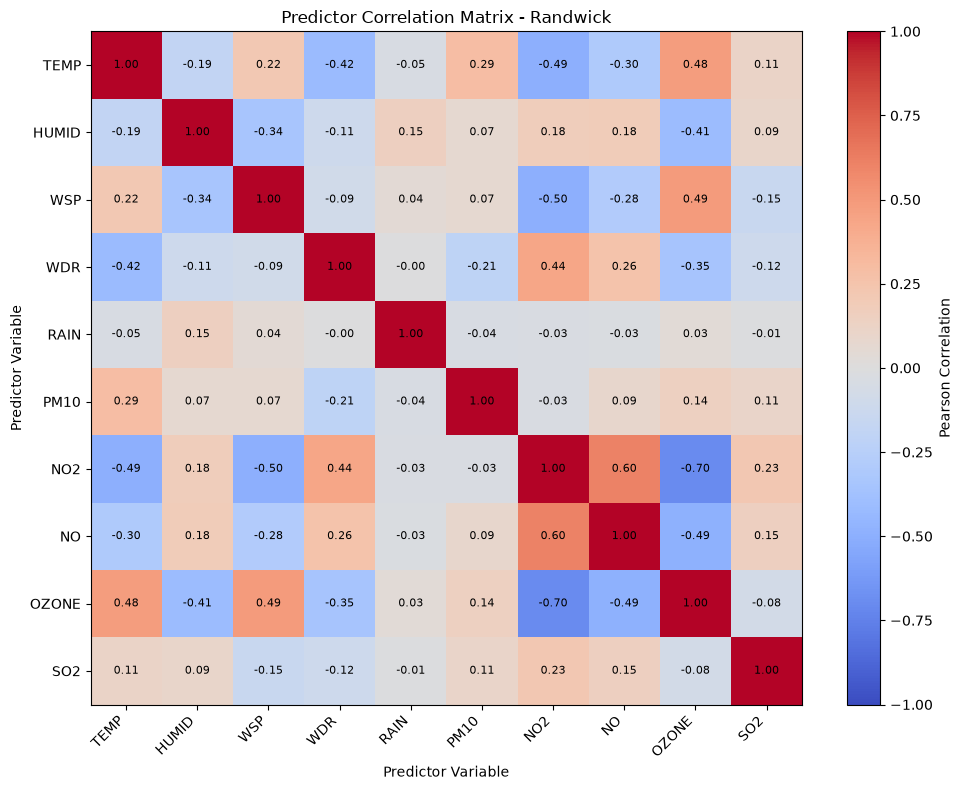

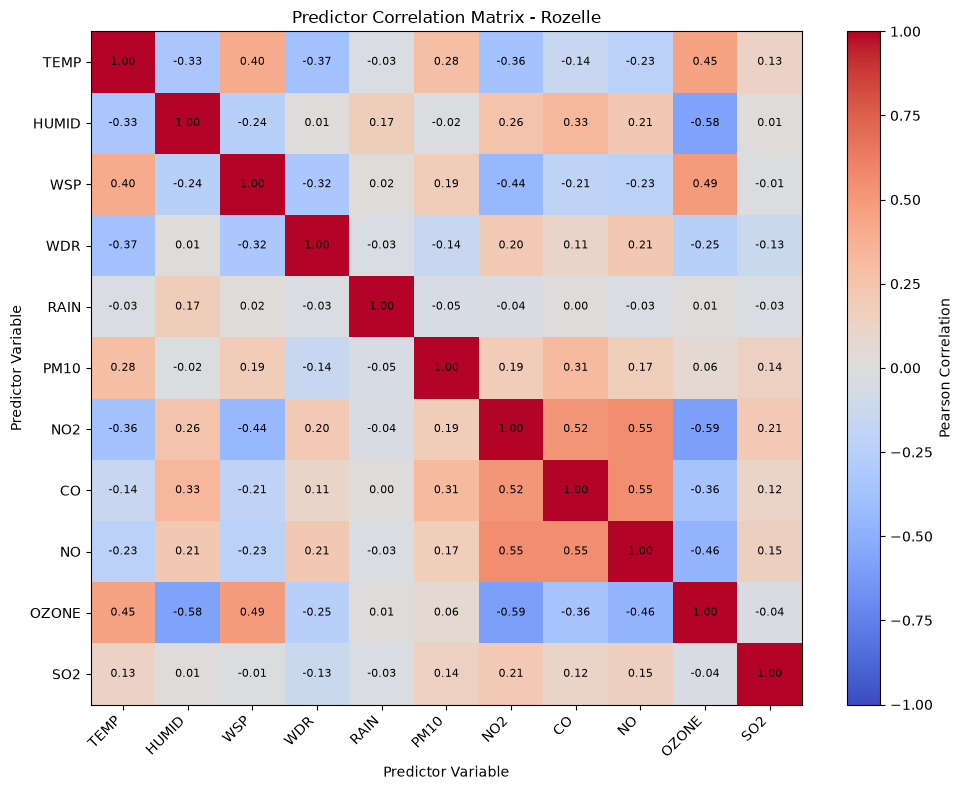

In [17]:
# Predictor variables to include in the correlation analysis
predictor_variables = [
    "TEMP",
    "HUMID",
    "WSP",
    "WDR",
    "RAIN",
    "PM10",
    "NO2",
    "CO",
    "NO",
    "OZONE",
    "SO2"
]

for station in retained_stations:
    df = eda_station_data[station].copy()

    # Build a mapping from short variable names to full column names
    variable_columns = {}

    for column in df.columns:
        column_upper = column.upper()

        for variable in predictor_variables:
            if f" {variable.upper()} 1H AVERAGE" in column_upper:
                variable_columns[variable] = column

    # Keep only predictors available at this station
    available_variables = [
        variable
        for variable in predictor_variables
        if variable in variable_columns
    ]

    predictor_data = df[
        [variable_columns[variable] for variable in available_variables]
    ].copy()

    # Rename columns using short variable names
    predictor_data.columns = available_variables

    # Calculate Pearson correlations
    predictor_correlation = predictor_data.corr(method="pearson")

    # Plot correlation matrix
    plt.figure(figsize=(10, 8))

    plt.imshow(
        predictor_correlation,
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        aspect="auto"
    )

    plt.colorbar(label="Pearson Correlation")

    plt.xticks(
        range(len(available_variables)),
        available_variables,
        rotation=45,
        ha="right"
    )

    plt.yticks(
        range(len(available_variables)),
        available_variables
    )

    # Add correlation values
    for i in range(len(available_variables)):
        for j in range(len(available_variables)):
            value = predictor_correlation.iloc[i, j]

            if pd.notna(value):
                plt.text(
                    j,
                    i,
                    f"{value:.2f}",
                    ha="center",
                    va="center",
                    fontsize=8
                )

    plt.xlabel("Predictor Variable")
    plt.ylabel("Predictor Variable")
    plt.title(f"Predictor Correlation Matrix - {station}")

    plt.tight_layout()

    plt.savefig(
        figures_dir / f"predictor_correlation_matrix_{station.lower().replace(' ', '_')}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

###### **Predictor Relationship Interpretation (3.8.2)**

###### These results show which predictors are related to each other, not just to PM2.5.
###### - Several predictor variables show relationships with each other, indicating that some environmental and pollutant variables may contain overlapping information.
###### - NO2, NO and CO show moderate to strong positive correlations at several stations, with the strongest relationships generally observed between the pollutant variables.
###### - Humidity and ozone show strong negative correlations across most stations, while temperature and ozone generally show positive correlations.
###### - Temperature and humidity also show negative correlations across the monitoring stations, with wind speed generally showing a negative relationship with humidity.
###### - Rainfall and wind direction generally show weak relationships with the other predictor variables.
###### - The strength of predictor relationships varies between monitoring stations, indicating that the relationships between environmental variables are not identical across locations.
###### - These results suggest that some predictors may provide overlapping information when used together in machine learning models.
###### - The predictor correlations will be considered when interpreting the feature-importance results of the subsequent modelling analysis.

#### 3.9 Lag Relationship Analysis

Lag analysis is used to examine whether PM2.5 concentrations are related to their previous hourly values and to investigate whether selected predictor variables show relationships with PM2.5 at earlier time points. This is useful for identifying temporal dependence in the hourly air-quality data and provides an initial assessment of patterns that may be relevant to time-series modelling.

##### 3.9.1 PM2.5 Autocorrelation Across Time Lags

The autocorrelation of PM2.5 is examined at selected hourly lags to determine whether current PM2.5 concentrations are associated with concentrations measured in previous hours.

In [18]:
# Selected time lags in hours
selected_lags = [1, 3, 6, 12, 24, 48]

pm25_lag_results = []

for station in retained_stations:
    df = eda_station_data[station].copy()

    # Identify PM2.5 column
    pm25_column = [
        column for column in df.columns
        if "PM2.5" in column.upper()
    ][0]

    pm25 = df[pm25_column]

    for lag in selected_lags:
        lagged_data = pd.DataFrame({
            "Current_PM25": pm25,
            "Lagged_PM25": pm25.shift(lag)
        }).dropna()

        correlation = lagged_data["Current_PM25"].corr(
            lagged_data["Lagged_PM25"],
            method="pearson"
        )

        pm25_lag_results.append({
            "Station": station,
            "Lag_Hours": lag,
            "Pearson_Correlation": correlation
        })

pm25_lag_results_df = pd.DataFrame(pm25_lag_results)

display(pm25_lag_results_df)

,Station,Lag_Hours,Pearson_Correlation
0,Camden,1,0.870320
1,Camden,3,0.580234
2,Camden,6,0.404293
3,Camden,12,0.266469
4,Camden,24,0.179065
5,Camden,48,0.194678
6,Liverpool,1,0.856611
7,Liverpool,3,0.581998
8,Liverpool,6,0.361609
9,Liverpool,12,0.195180


In [19]:
# Save PM2.5 lag correlation results
lag_correlation_output_path = tables_dir / "pm25_lag_correlations_by_station.csv"

pm25_lag_results_df.to_csv(
    lag_correlation_output_path,
    index=False
)

print(f"Lag correlation results saved to: {lag_correlation_output_path}")

Lag correlation results saved to: ..\results\tables\pm25_lag_correlations_by_station.csv


###### **Lag Relationship Interpretation (3.9.1)**

###### - PM2.5 shows a strong positive temporal relationship at a 1-hour lag across all monitoring stations, with correlations above 0.80.
###### - The correlation decreases as the time lag increases, indicating that the influence of previous PM2.5 concentrations becomes weaker over longer time intervals.
###### - Moderate positive relationships remain at 3- and 6-hour lags, while weaker positive relationships are still present at 12-, 24- and 48-hour lags.
###### - The continued positive correlations at longer lags indicate that PM2.5 concentrations are not completely independent from previous observations.
###### - Rozelle has the strongest 1-hour temporal correlation, while Prospect has the lowest among the seven stations.
###### - Randwick shows the weakest relationship at the 48-hour lag.
###### - At several stations, the 24-hour correlation is higher than the 12-hour correlation, suggesting that some similarity may remain across approximately one day.
###### - Overall, the results demonstrate clear temporal dependence in the hourly PM2.5 data, which supports the use of time-series approaches such as LSTM in the later modelling stage.

#### 3.9.2 Lag Correlation Visualisation

The Pearson correlations at the selected time lags are visualised to compare the temporal dependence of PM2.5 across the monitoring stations. This provides a clearer view of how the relationship between current and previous PM2.5 concentrations changes as the time lag increases.

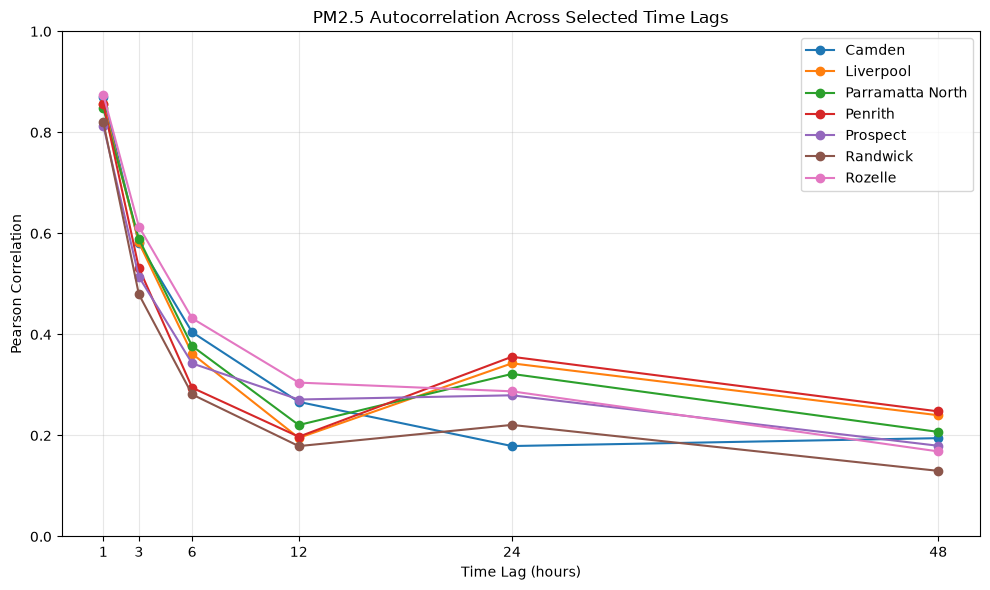

In [20]:
# Plot PM2.5 lag correlations for all stations

plt.figure(figsize=(10, 6))

for station in retained_stations:
    station_data = pm25_lag_results_df[
        pm25_lag_results_df["Station"] == station
    ].sort_values("Lag_Hours")

    plt.plot(
        station_data["Lag_Hours"],
        station_data["Pearson_Correlation"],
        marker="o",
        linewidth=1.5,
        label=station
    )

plt.xlabel("Time Lag (hours)")
plt.ylabel("Pearson Correlation")
plt.title("PM2.5 Autocorrelation Across Selected Time Lags")
plt.xticks(selected_lags)
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    figures_dir / "pm25_lag_correlation_by_station.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

###### **Lag Correlation Visualisation Interpretation (3.9.2)**

###### Autocorrelation - How similar a variable is to its own past values

###### - The plot shows a strong positive correlation between current PM2.5 and PM2.5 measured one hour earlier across all monitoring stations.
###### - The correlations generally decrease as the time lag increases, showing that the influence of recent PM2.5 observations is stronger than observations further in the past.
###### - Positive correlations remain at the 24- and 48-hour lags, although they are generally weaker than the short-term relationships.
###### - The stations show similar overall declining patterns, but the strength of the temporal relationships differs between locations.
###### - Some stations show a small increase in correlation at the 24-hour lag compared with the 12-hour lag, indicating that observations approximately one day apart may retain some similarity.
###### - Overall, the visualisation confirms that PM2.5 has temporal dependence, supporting the use of time-series modelling in the later analysis.

##### 3.9.3 Lagged Predictor Relationships with PM2.5

Lagged correlations are examined between PM2.5 and selected predictor variables at previous time points. This analysis investigates whether predictor values from earlier hours are associated with current PM2.5 concentrations and provides an additional assessment of temporal relationships in the dataset.

In [21]:
# Selected predictors for lagged relationship analysis
lagged_predictors = [
    "PM10",
    "CO",
    "NO2",
    "NO",
    "TEMP",
    "WSP"
]

predictor_lags = [1, 3, 6, 12, 24]

lagged_predictor_results = []

for station in retained_stations:
    df = eda_station_data[station].copy()

    # Identify PM2.5 column
    pm25_column = [
        column for column in df.columns
        if "PM2.5" in column.upper()
    ][0]

    # Identify predictor columns using exact variable matching
    variable_columns = {}

    for column in df.columns:
        column_upper = column.upper()

        for variable in lagged_predictors:
            if f" {variable.upper()} 1H AVERAGE" in column_upper:
                variable_columns[variable] = column

    for variable in lagged_predictors:

        # Skip predictors unavailable at this station
        if variable not in variable_columns:
            continue

        predictor_column = variable_columns[variable]

        for lag in predictor_lags:

            lagged_data = pd.DataFrame({
                "PM2.5": df[pm25_column],
                "Lagged_Predictor": df[predictor_column].shift(lag)
            }).dropna()

            correlation = lagged_data["PM2.5"].corr(
                lagged_data["Lagged_Predictor"],
                method="pearson"
            )

            lagged_predictor_results.append({
                "Station": station,
                "Variable": variable,
                "Lag_Hours": lag,
                "Pearson_Correlation": correlation
            })

lagged_predictor_results_df = pd.DataFrame(
    lagged_predictor_results
)

display(
    lagged_predictor_results_df.sort_values(
        ["Station", "Variable", "Lag_Hours"]
    )
)

,Station,Variable,Lag_Hours,Pearson_Correlation
5,Camden,CO,1,0.573876
6,Camden,CO,3,0.429165
7,Camden,CO,6,0.288845
8,Camden,CO,12,0.242489
9,Camden,CO,24,0.158252
...,...,...,...,...
200,Rozelle,WSP,1,-0.038635
201,Rozelle,WSP,3,-0.052435
202,Rozelle,WSP,6,-0.041149
203,Rozelle,WSP,12,-0.026305


In [22]:
# Save lagged predictor correlation results
lagged_predictor_output_path = (
    tables_dir / "lagged_predictor_correlations_by_station.csv"
)

lagged_predictor_results_df.to_csv(
    lagged_predictor_output_path,
    index=False
)

print(
    f"Lagged predictor correlation results saved to: "
    f"{lagged_predictor_output_path}"
)

Lagged predictor correlation results saved to: ..\results\tables\lagged_predictor_correlations_by_station.csv


###### **Lagged Predictor Relationship Interpretation (3.9.3)**

###### - PM10 generally shows the strongest positive lagged relationship with current PM2.5, particularly at the 1-hour lag.
###### - CO also shows positive lagged relationships with PM2.5 at most stations where it is available.
###### - NO2 and NO generally show positive relationships with later PM2.5 concentrations, with stronger relationships at shorter time lags.
###### - Temperature shows mostly weak lagged relationships with PM2.5, while wind speed generally shows negative relationships.
###### - For most predictors, the strength of the relationship decreases as the time lag increases.
###### - Penrith differs from the other stations, particularly for PM10, which shows a very weak lagged relationship with PM2.5.
###### - The results indicate that recent pollutant conditions, particularly PM10 and CO, may be more closely associated with subsequent PM2.5 concentrations than conditions further in the past.
###### - These results represent temporal associations rather than causal effects and provide additional information for the later time-series modelling stage.

#### 3.10 Stationarity Analysis

Stationarity analysis is conducted to assess whether the statistical properties of the PM2.5 time series remain relatively stable over time. The Augmented Dickey-Fuller (ADF) test is used as an initial statistical test of stationarity for PM2.5 at each monitoring station.

##### 3.10.1 Augmented Dickey-Fuller Test

The Augmented Dickey-Fuller (ADF) test is applied to the PM2.5 time series at each monitoring station. The test evaluates the null hypothesis that the time series contains a unit root and is therefore non-stationary.

In [23]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
# testing if statmodels was downloaded properly 
from statsmodels.tsa.stattools import adfuller

print("ADF test library loaded successfully.")

ADF test library loaded successfully.


In [25]:
# Run the Augmented Dickey-Fuller (ADF) test for PM2.5 at each station
# This helps us check whether the PM2.5 time series is stationary or non-stationary

adf_results = []

for station in retained_stations:
    # Get the preprocessed data for the current station
    df = eda_station_data[station].copy()

    # Find the PM2.5 column
    pm25_column = [
        column for column in df.columns
        if "PM2.5" in column.upper()
    ][0]

    # Remove missing PM2.5 values before running the test
    pm25 = df[pm25_column].dropna()

    # Run the Augmented Dickey-Fuller test
    adf_result = adfuller(pm25)

    # Store the main results so we can compare all stations
    adf_results.append({
        "Station": station,
        "ADF_Statistic": adf_result[0],
        "p_value": adf_result[1],
        "Used_Observations": adf_result[3],
        "Stationary_at_5pct": adf_result[1] < 0.05
    })

# Put the results into a table
adf_results_df = pd.DataFrame(adf_results)

# Display the stationarity results
display(adf_results_df)

C:\Users\Safa Rawoot\AppData\Local\Temp\ipykernel_27448\3635114233.py:20: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(pm25)
C:\Users\Safa Rawoot\AppData\Local\Temp\ipykernel_27448\3635114233.py:20: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(pm25)
C:\Users\Safa Rawoot\AppData\Local\Temp\ipykernel_27448\3635114233.py:20: Futu

,Station,ADF_Statistic,p_value,Used_Observations,Stationary_at_5pct
0,Camden,-21.019149,0.0,56072,True
1,Liverpool,-21.304205,0.0,56268,True
2,Parramatta North,-21.074156,0.0,55858,True
3,Penrith,-23.206276,0.0,52617,True
4,Prospect,-20.674383,0.0,54472,True
5,Randwick,-21.059701,0.0,56767,True
6,Rozelle,-21.949988,0.0,56904,True


In [26]:
# Save the ADF test results so we can use them later in the report
adf_results_path = tables_dir / "pm25_stationarity_test_results.csv"

adf_results_df.to_csv(adf_results_path, index=False)

print(f"ADF stationarity results saved to: {adf_results_path}")

ADF stationarity results saved to: ..\results\tables\pm25_stationarity_test_results.csv


###### **Interpretation for ADF Stationarity Results (3.10.1)**

###### - The ADF test indicated that PM2.5 was stationary at all seven monitoring stations.
###### - All stations had p-values below 0.05, so the null hypothesis of non-stationarity was rejected.
###### - This suggests that the PM2.5 series does not exhibit a unit-root type non-stationarity over the analysed period.
###### - No differencing was therefore applied to PM2.5 at this preprocessing/EDA stage.

#### 3.11 Missing-Value Analysis

After preprocessing and short-gap interpolation, some missing values remain in the datasets. These missing values mainly occur because of prolonged gaps or because certain variables, such as rainfall and wind direction, were not interpolated using ordinary linear interpolation.

The remaining missing values are examined to understand their distribution across stations and variables before the modelling stage.

##### 3.11.1 Missing-value Percentage by Station and Variable

In [30]:
# Calculate the percentage of missing values for each available variable
# at each station after preprocessing

missing_percentage_records = []

for station in retained_stations:
    # Get the preprocessed data for this station
    df = eda_station_data[station].copy()

    # Check each variable separately
    for variable in analysis_variables:

        # Find the exact variable in the column name.
        # The spaces around the variable help prevent NO from matching NO2.
        matching_columns = [
            column for column in df.columns
            if f" {variable.upper()} 1H AVERAGE" in column.upper()
        ]

        # Skip the variable if it is not available at this station
        if not matching_columns:
            continue

        column = matching_columns[0]

        # Count the remaining missing values
        missing_count = df[column].isna().sum()

        # Convert the count into a percentage
        missing_percentage = (missing_count / len(df)) * 100

        missing_percentage_records.append({
            "Station": station,
            "Variable": variable,
            "Missing_Count": missing_count,
            "Missing_Percentage": missing_percentage
        })

# Create a table from the results
missing_percentage_df = pd.DataFrame(missing_percentage_records)

# Keep only variables that still have missing values
missing_percentage_df = missing_percentage_df[
    missing_percentage_df["Missing_Count"] > 0
].sort_values(
    by="Missing_Percentage",
    ascending=False
)

display(missing_percentage_df)

,Station,Variable,Missing_Count,Missing_Percentage
63,Randwick,RAIN,24524,42.736651
28,Parramatta North,RAIN,20625,35.942074
5,Camden,RAIN,15164,26.425484
16,Liverpool,RAIN,15035,26.200683
19,Liverpool,CO,15005,26.148404
...,...,...,...,...
13,Liverpool,HUMID,182,0.317162
12,Liverpool,TEMP,145,0.252684
27,Parramatta North,WDR,103,0.179493
17,Liverpool,PM10,87,0.151610


In [32]:
# Save the remaining missing-value summary for later analysis and reporting
missing_percentage_path = tables_dir / "remaining_missing_values_by_station.csv"

missing_percentage_df.to_csv(
    missing_percentage_path,
    index=False
)

print(f"Missing-value summary saved to: {missing_percentage_path}")

Missing-value summary saved to: ..\results\tables\remaining_missing_values_by_station.csv


##### 3.11.2 Visualise Missingness using Heatmap

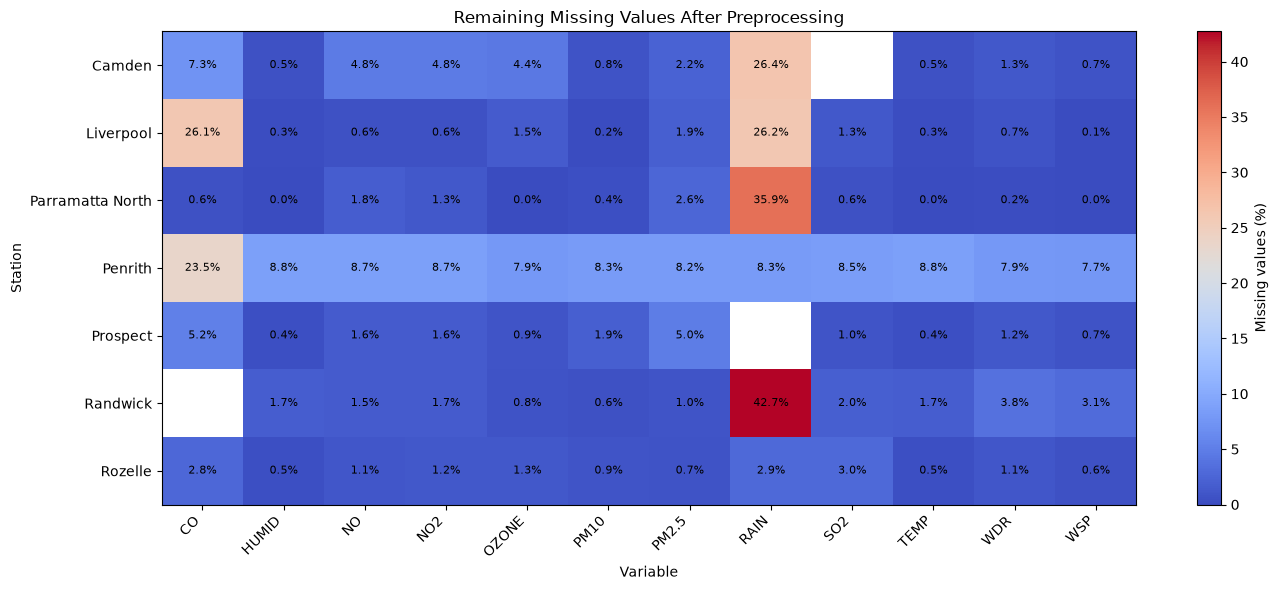

Figure saved to: ..\results\figures\remaining_missing_values_heatmap.png


In [35]:
# Create a heatmap showing the percentage of remaining missing values
# Unavailable variables are kept separate from variables with 0% missing values
# Blue represents lower missingness and red represents higher missingness


# Recalculate the missing percentages for all available variables,
# including variables that have 0% missing values
all_missing_records = []

for station in retained_stations:
    # Get the preprocessed data for this station
    df = eda_station_data[station].copy()

    for variable in analysis_variables:

        # Find the exact variable name in the column names
        # This prevents NO from being confused with NO2 or NORTH
        matching_columns = [
            column for column in df.columns
            if f" {variable.upper()} 1H AVERAGE" in column.upper()
        ]

        # If the variable is not available at this station,
        # leave it as unavailable rather than treating it as 0% missing
        if not matching_columns:
            all_missing_records.append({
                "Station": station,
                "Variable": variable,
                "Missing_Percentage": np.nan
            })
            continue

        column = matching_columns[0]

        # Calculate the percentage of missing observations
        missing_percentage = df[column].isna().mean() * 100

        all_missing_records.append({
            "Station": station,
            "Variable": variable,
            "Missing_Percentage": missing_percentage
        })

# Convert the results into a table
all_missing_df = pd.DataFrame(all_missing_records)

# Arrange the data so stations are rows and variables are columns
missing_pivot = all_missing_df.pivot(
    index="Station",
    columns="Variable",
    values="Missing_Percentage"
)

# Create the heatmap
plt.figure(figsize=(14, 6))

plt.imshow(
    missing_pivot,
    aspect="auto",
    cmap="coolwarm"
)

plt.colorbar(label="Missing values (%)")

# Add variable names to the x-axis
plt.xticks(
    range(len(missing_pivot.columns)),
    missing_pivot.columns,
    rotation=45,
    ha="right"
)

# Add station names to the y-axis
plt.yticks(
    range(len(missing_pivot.index)),
    missing_pivot.index
)

# Add the actual percentage values inside each cell
for row in range(len(missing_pivot.index)):
    for col in range(len(missing_pivot.columns)):

        value = missing_pivot.iloc[row, col]

        # Only write a value if the variable is available
        if not pd.isna(value):
            plt.text(
                col,
                row,
                f"{value:.1f}%",
                ha="center",
                va="center",
                fontsize=8
            )

plt.xlabel("Variable")
plt.ylabel("Station")
plt.title("Remaining Missing Values After Preprocessing")

plt.tight_layout()

missingness_figure_path = figures_dir / "remaining_missing_values_heatmap.png"

plt.savefig(
    missingness_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved to: {missingness_figure_path}")

###### **Interpretation for Missing-Value Analysis (3.11)**

###### - Short gaps of up to 48 hours were interpolated for the selected variables during preprocessing.
###### - The remaining missing values for these variables mainly correspond to longer gaps that were not interpolated.
###### - Rainfall (RAIN) and wind direction (WDR) were excluded from ordinary linear interpolation, so their remaining missing values include gaps that were not filled during preprocessing.
###### - Rainfall has the highest missingness at several stations, particularly Randwick (42.7%) and Parramatta North (35.9%).
###### - Liverpool also has substantial missingness in CO (26.1%).
###### - Penrith has relatively high missingness across many variables compared with the other stations.
###### - The remaining missing values will be handled when constructing the modelling datasets.
###### - The remaining missing values will be considered when constructing the modelling datasets.